In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns


In [4]:
df = pd.read_csv('bank.csv')

In [5]:
df.shape

(4521, 1)

In [6]:
df.info

<bound method DataFrame.info of      age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"
0     30;"unemployed";"married";"primary";"no";1787;...                                                                                                  
1     33;"services";"married";"secondary";"no";4789;...                                                                                                  
2     35;"management";"single";"tertiary";"no";1350;...                                                                                                  
3     30;"management";"married";"tertiary";"no";1476...                                                                                                  
4     59;"blue-collar";"married";"secondary";"no";0;...                                                                                                  
...                                         

In [7]:
df = pd.read_csv('bank.csv',sep=';') # re.load file using ";" separator

In [8]:
df.shape

(4521, 17)

In [10]:
df['balance'].describe

<bound method NDFrame.describe of 0       1787
1       4789
2       1350
3       1476
4          0
        ... 
4516    -333
4517   -3313
4518     295
4519    1137
4520    1136
Name: balance, Length: 4521, dtype: int64>

In [11]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


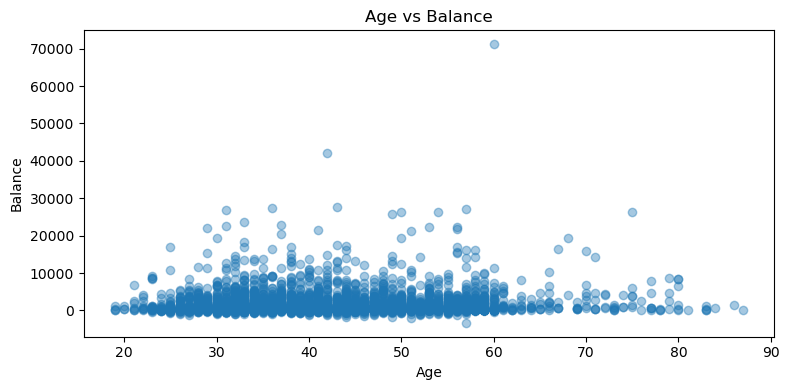

In [12]:
# Age Vs Balance

plt.figure(figsize=(8,4))
plt.scatter(df['age'],df['balance'],alpha=0.4)
plt.title('Age vs Balance')
plt.xlabel('Age')   
plt.ylabel('Balance')   
plt.tight_layout()

In [16]:
num_df = df.select_dtypes(include='int64')
num_df.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [17]:
X = num_df.drop('balance',axis=1)
y = num_df['balance']


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split (
    X, y,
    test_size=0.2,
    random_state=42 
)

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
lr = LinearRegression()

In [25]:
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [26]:
y_pred = lr.predict(X_test_scaled)

In [27]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

In [28]:
mae = mean_absolute_error(y_test, y_pred)   
r2 = r2_score(y_test, y_pred)
rmse = mean_absolute_error(y_test, y_pred)


In [29]:
print(mae)

1679.0022185564644


In [30]:
print(r2)

0.0005918428028857114


In [31]:
print(rmse)

1679.0022185564644


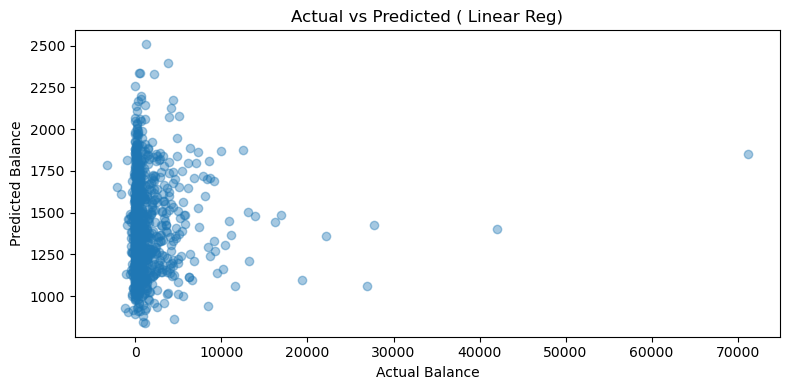

In [32]:
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Balance")
plt.ylabel("Predicted Balance")
plt.title("Actual vs Predicted ( Linear Reg)")
plt.tight_layout()